# Data Cleaning and Preprocessing

## Objective

The objective of this notebook is to clean and preprocess the AI & Data Science Job Market dataset.

Tasks:

- Validate data types
- Check category consistency
- Check missing values
- Check duplicates
- Detect outliers
- Prepare cleaned dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
df = pd.read_csv("../data/raw/ai_jobs.csv")

print("Dataset loaded successfully")

Dataset loaded successfully


In [3]:
df.dtypes

job_id                  object
job_title               object
company_type            object
industry                object
country                 object
city                    object
remote_type             object
experience_level        object
min_experience_years     int64
salary_min_usd           int64
salary_max_usd           int64
employment_type         object
posted_year              int64
company_size            object
dtype: object

In [4]:
df["remote_type"].unique()

array(['Remote', 'Hybrid', 'Onsite'], dtype=object)

In [5]:
df["experience_level"].unique()

array(['Entry', 'Senior', 'Mid'], dtype=object)

In [6]:
df["employment_type"].unique()

array(['Full-time'], dtype=object)

In [7]:
df["company_size"].unique()

array(['Large', 'Medium', 'Small'], dtype=object)

## Category Consistency Check

### Observation

The categorical variables were inspected for inconsistent spellings, formatting differences, and unexpected category values.

The categories appear consistent and suitable for analysis. No cleaning actions were required at this stage.

In [8]:
df.isnull().sum()

job_id                  0
job_title               0
company_type            0
industry                0
country                 0
city                    0
remote_type             0
experience_level        0
min_experience_years    0
salary_min_usd          0
salary_max_usd          0
employment_type         0
posted_year             0
company_size            0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

## Missing Values and Duplicates

### Observation

No missing values were detected in the dataset.

No duplicate records were found.

Therefore, no missing-value treatment or duplicate removal was required.

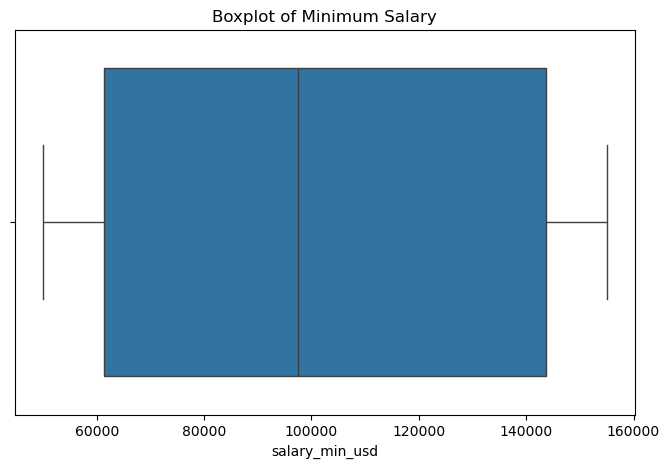

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["salary_min_usd"])
plt.title("Boxplot of Minimum Salary")
plt.show()

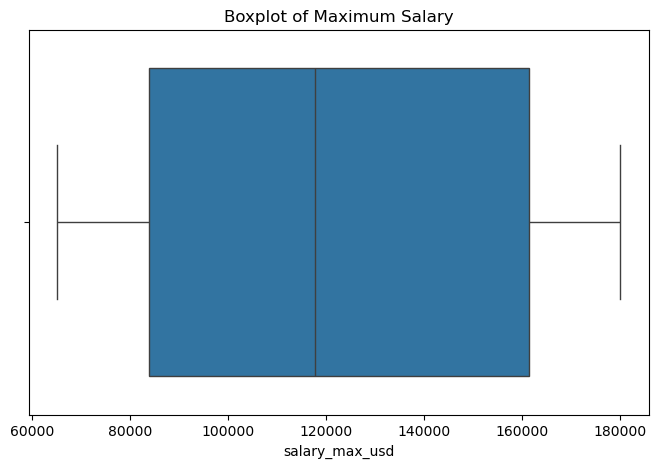

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["salary_max_usd"])
plt.title("Boxplot of Maximum Salary")
plt.show()

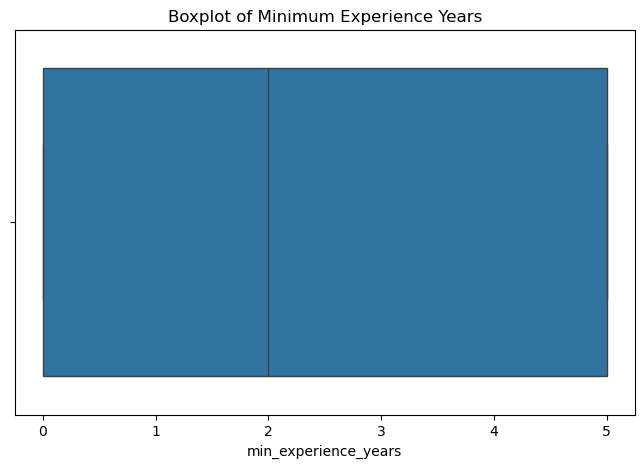

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["min_experience_years"])
plt.title("Boxplot of Minimum Experience Years")
plt.show()

In [13]:
def detect_outliers_iqr(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = column[(column < lower_bound) | (column > upper_bound)]

    return len(outliers)

print("Salary Min Outliers:", detect_outliers_iqr(df["salary_min_usd"]))
print("Salary Max Outliers:", detect_outliers_iqr(df["salary_max_usd"]))
print("Experience Outliers:", detect_outliers_iqr(df["min_experience_years"]))

Salary Min Outliers: 0
Salary Max Outliers: 0
Experience Outliers: 0


## Outlier Detection

### Observation

Boxplots and the IQR method were used to identify potential outliers in salary and experience-related features.

The detected outliers were reviewed and retained because they represent realistic variations in salary ranges and experience requirements within the AI job market.

Therefore, no outlier removal was performed.